# Heart Failure Clinical Records Dataset – Machine Test Questions

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [11]:
#Please enter your own file's path to get accurate answers.
df = pd.read_csv("C:\\Users\\edwin\\OneDrive\\Desktop\\development_journey\\20.Machine Learning\\ml_exam_june_09\\Heart_failure_clinical_records_dataset - Heart_failure_clinical_records_dataset.csv")

In [ ]:
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


## 1. Which age group of patients shows the highest mortality rate? Support your answer with appropriate analysis and visualization.

In [ ]:
df["age"].value_counts()  #Observe ages and create bins accordingly 
#bins ---> bins are intervals (ranges) used to group continuous numerical data into categories.

age_group
<40       0.000000
40-50    28.358209
50-60    28.409091
60-70    24.705882
70-80    52.941176
80+      72.222222
Name: DEATH_EVENT, dtype: float64


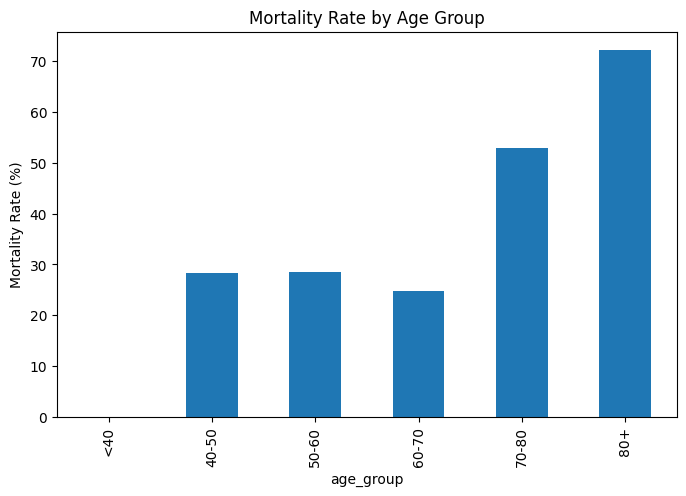

In [ ]:
age_bins = [0, 40, 50, 60, 70, 80, 100]  #This creates the boundaries for age groups. 

age_labels = ['<40', '40-50', '50-60', '60-70', '70-80', '80+'] #Graph labels 

df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels) #pd.cut()--> pd.cut() is a Pandas function used to convert continuous numerical values into bins.
#we assigned a new column name  "age_group"

#further explanation under  graph
mortality_age = df.groupby('age_group')['DEATH_EVENT'].mean() * 100  #groupby() is one of the most important Pandas functions. It means:
#"Group rows that have the same value, then perform a calculation on each group."

print(mortality_age) #shows percent of death in each age group

#Died --> 1, Survived -->0 ;Mortality Rate= (Number of Deaths(1's)/Total Patients) * 100

plt.figure(figsize=(8,5)) 

mortality_age.plot(kind='bar') #kind can be barh,hist,pie,line etc Try yourself

plt.ylabel("Mortality Rate (%)")
plt.title("Mortality Rate by Age Group")
plt.show()

#### explain the line mortality_age = df.groupby('age_group')['DEATH_EVENT'].mean() * 100
When you see:
df.groupby('age_group')['DEATH_EVENT'].mean() * 100
the key idea is that **`DEATH_EVENT` contains only 0s and 1s**:

* `0` = Survived
* `1` = Died

#### Step 1: Group by age group

Suppose the 60–70 age group has:

| Patient | DEATH_EVENT |
| ------- | ----------- |
| A       | 1           |
| B       | 0           |
| C       | 1           |
| D       | 0           |
| E       | 1           |


#### Step 2: Calculate the mean

(1 + 0 + 1 + 0 + 1) / 5  = 3 / 5  = 0.6

#### Step 3: Interpret the result

A mean of 0.6 means 60% of patients died
because 3 out of 5 patients had `DEATH_EVENT = 1(Dead)`.


#### Step 4: Multiply by 100

.mean() * 100
converts the proportion into a percentage:
0.6 * 100
= 60%


So the mortality rate is:
60%


For binary columns (0 and 1), the mean directly represents the proportion of 1s, which in this dataset is the **mortality rate**.


## 2. Is there a significant difference in mortality between male and female patients? Analyze and justify your findings.

Female    32.380952
Male      31.958763
Name: DEATH_EVENT, dtype: float64


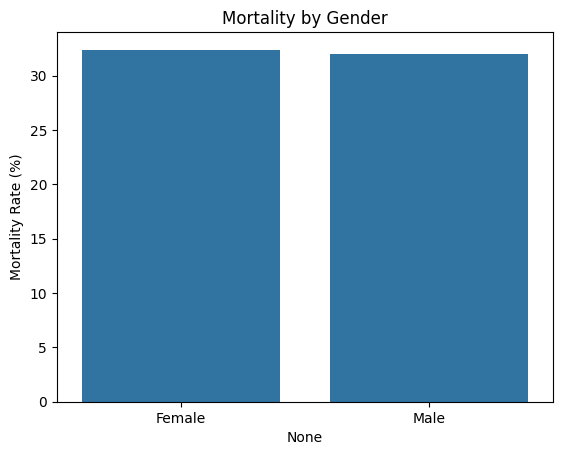

In [ ]:
gender_mortality = df.groupby('sex')['DEATH_EVENT'].mean() * 100  #(Death grouped by sex(Male/Female))

gender_mortality.index = ['Female','Male']  #We are labelling the index 0 ,1 as Female,Male

print(gender_mortality) #female mortality rate -->(female_deaths / female_total) * 100 = 32%

sns.barplot(
    x=gender_mortality.index,      #can also plot as plt.bar(...)
    y=gender_mortality.values
)

plt.ylabel("Mortality Rate (%)")
plt.title("Mortality by Gender")
plt.show()

## 3. How does ejection fraction influence patient survival? Identify the ejection fraction range associated with the highest risk.

##### Understand the question, you need a boxplot to show the effect ejection fraction(Percentage of blood leaving the heart at each contraction) has on patient's survival . They are usually inversely proportional. Lower the EF ,higher the chance of death. 

explanation diagram below boxplot

ejection_fraction
(0, 20]      86.956522
(20, 30]     44.285714
(30, 40]     20.634921
(40, 50]     26.829268
(50, 100]    20.512821
Name: DEATH_EVENT, dtype: float64


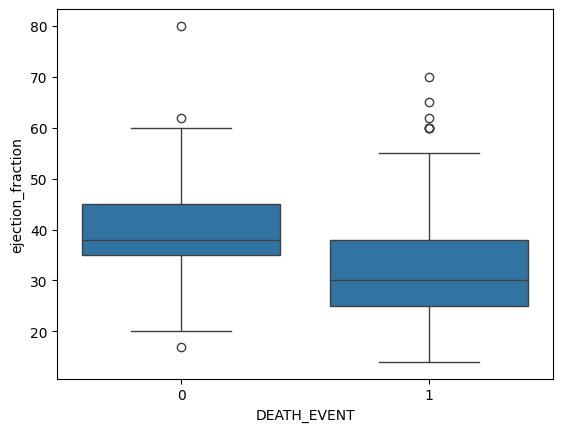

In [ ]:

# Visualization
sns.boxplot(
    x='DEATH_EVENT',
    y='ejection_fraction',
    data=df
)

# Quantitative analysis :
risk_group = pd.cut(
    df['ejection_fraction'],
    bins=[0,20,30,40,50,100]  #EF range(lower range,higher mortaity percent) (named as risk_group)
)

print(
    df.groupby(risk_group)['DEATH_EVENT'].mean()*100 #shows mortality rate 
)

A boxplot (box-and-whisker plot) is a graph that summarizes the distribution of a numerical variable.

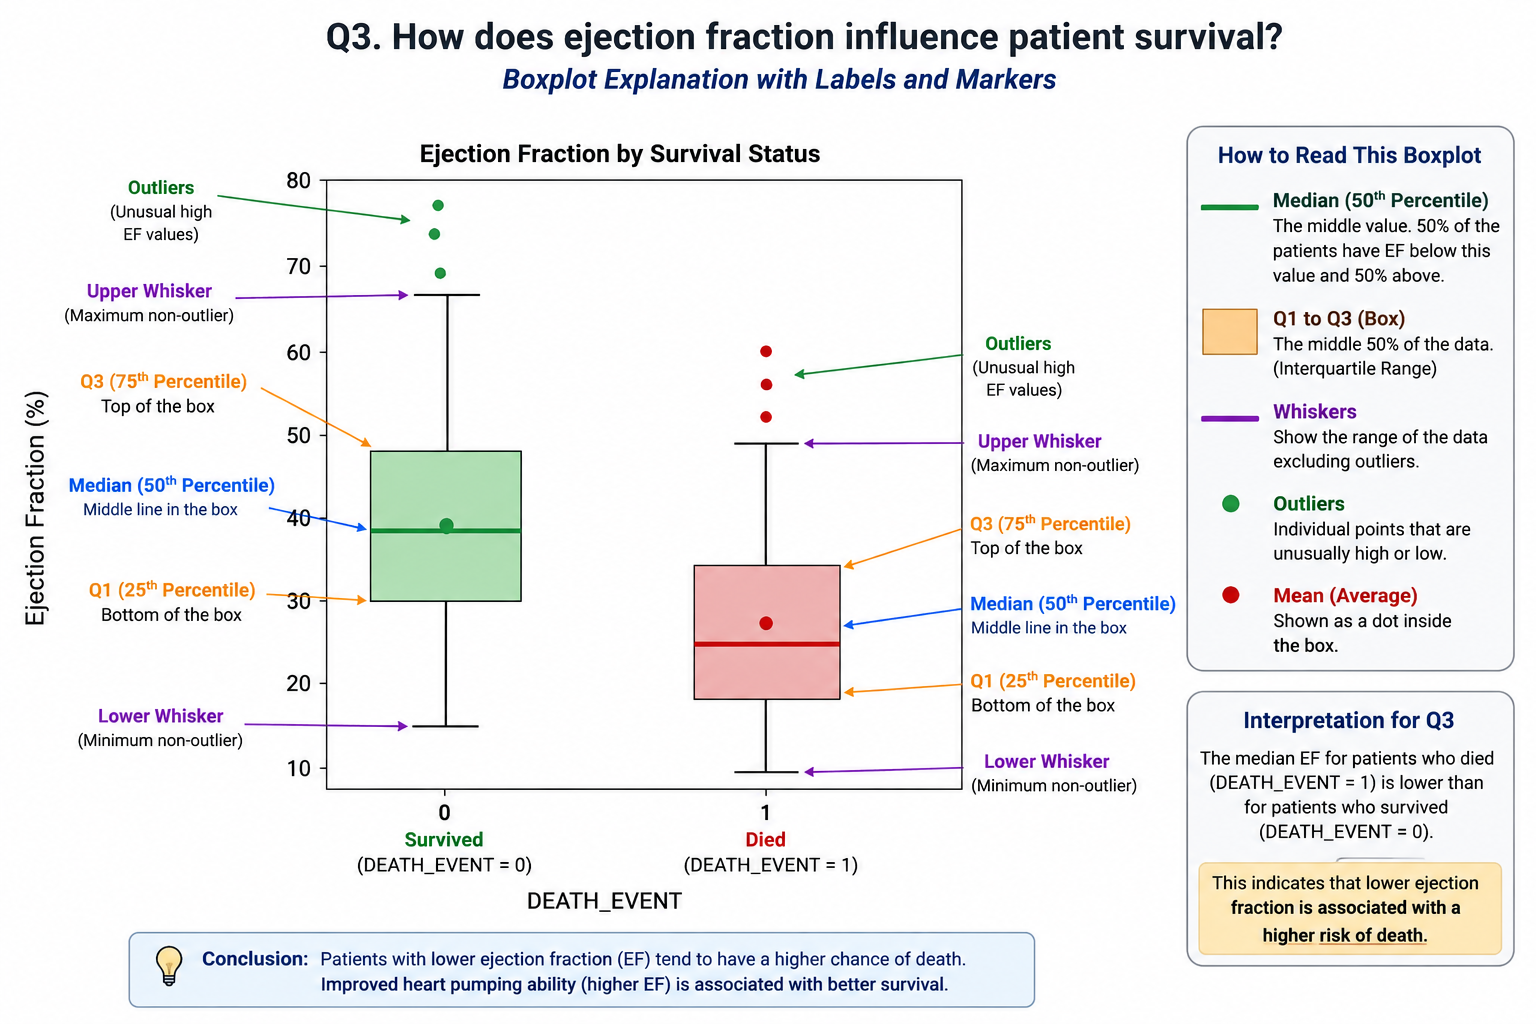


## 4. Compare the mortality rates of diabetic and non-diabetic patients. What insights can be derived from the analysis?


Non-Diabetic    32.183908
Diabetic        32.000000
Name: DEATH_EVENT, dtype: float64


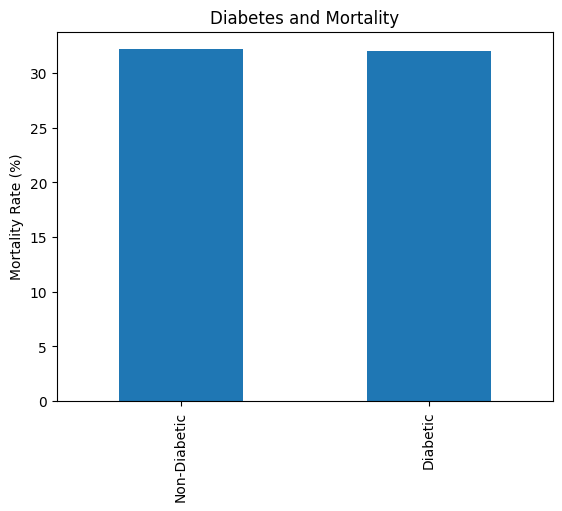

In [ ]:
diabetes_mortality = df.groupby('diabetes')['DEATH_EVENT'].mean()*100

diabetes_mortality.index = ['Non-Diabetic','Diabetic']

print(diabetes_mortality)

diabetes_mortality.plot(kind='bar')
plt.ylabel("Mortality Rate (%)")
plt.title("Diabetes and Mortality")
plt.show()

## 5.Does smoking increase the risk of death among heart failure patients? Provide evidence to support your conclusion.

Non-Smoker    32.512315
Smoker        31.250000
Name: DEATH_EVENT, dtype: float64


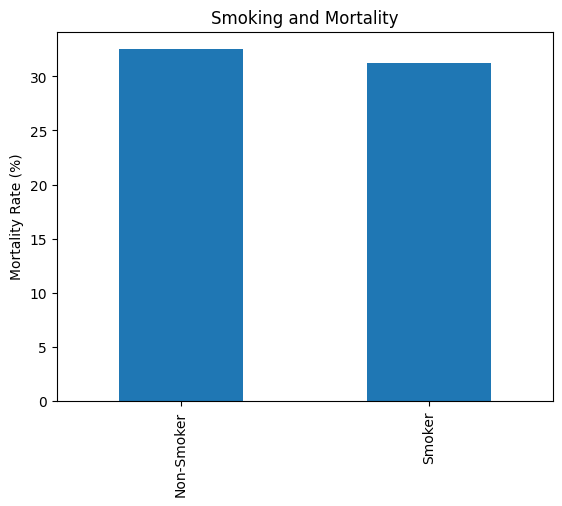

In [ ]:
smoking_mortality = df.groupby('smoking')['DEATH_EVENT'].mean()*100

smoking_mortality.index = ['Non-Smoker','Smoker']

print(smoking_mortality)

smoking_mortality.plot(kind='bar')
plt.ylabel("Mortality Rate (%)")
plt.title("Smoking and Mortality")
plt.show()

## 6. Analyse the impact of high blood pressure on patient mortality. Is it a major risk factor in this dataset?

No HBP    29.381443
HBP       37.142857
Name: DEATH_EVENT, dtype: float64


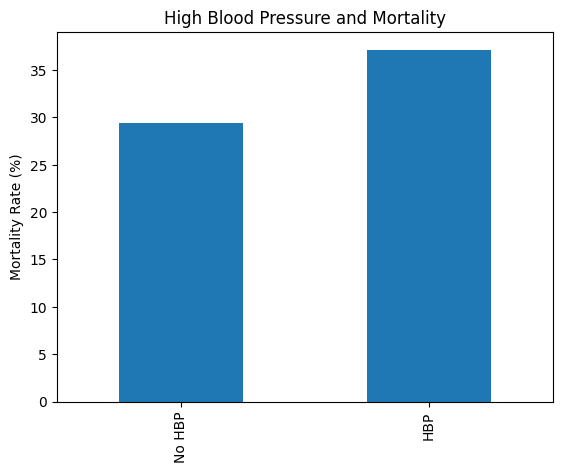

In [ ]:
bp_mortality = df.groupby('high_blood_pressure')['DEATH_EVENT'].mean()*100

bp_mortality.index = ['No HBP','HBP']

print(bp_mortality)

bp_mortality.plot(kind='bar')
plt.ylabel("Mortality Rate (%)")
plt.title("High Blood Pressure and Mortality")
plt.show()

## 7.Identify the common characteristics of patients who experienced a death event. Consider factors such as age, ejection fraction, serum creatinine, and other relevant features.

             age    anaemia  creatinine_phosphokinase   diabetes  \
count  96.000000  96.000000                 96.000000  96.000000   
mean   65.215281   0.479167                670.197917   0.416667   
std    13.214556   0.502188               1316.580640   0.495595   
min    42.000000   0.000000                 23.000000   0.000000   
25%    55.000000   0.000000                128.750000   0.000000   
50%    65.000000   0.000000                259.000000   0.000000   
75%    75.000000   1.000000                582.000000   1.000000   
max    95.000000   1.000000               7861.000000   1.000000   

       ejection_fraction  high_blood_pressure      platelets  \
count          96.000000             96.00000      96.000000   
mean           33.468750              0.40625  256381.044792   
std            12.525303              0.49371   98525.682856   
min            14.000000              0.00000   47000.000000   
25%            25.000000              0.00000  197500.000000   
50%

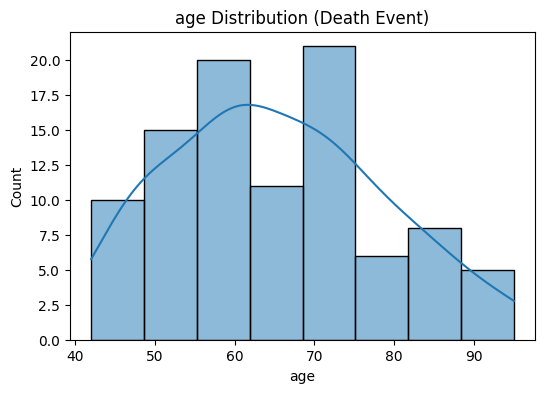

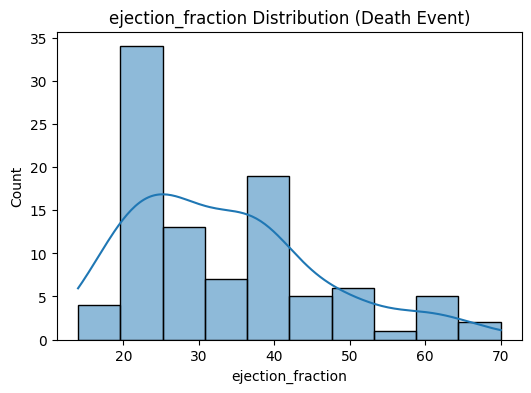

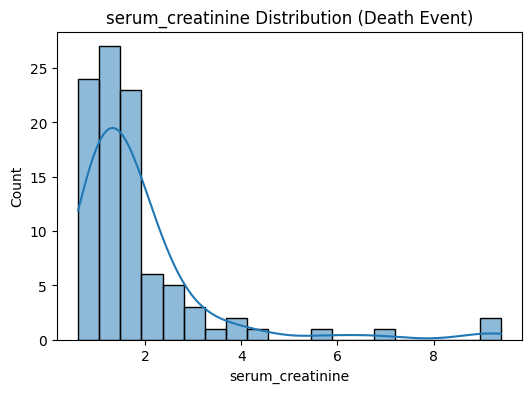

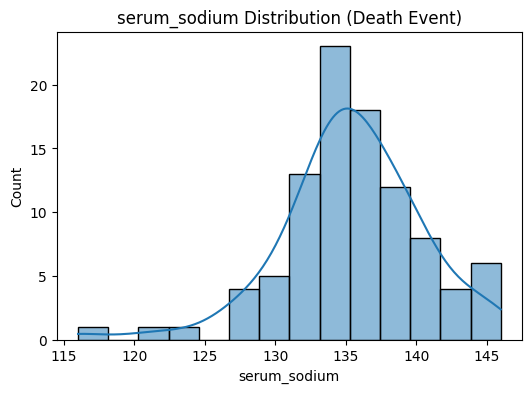

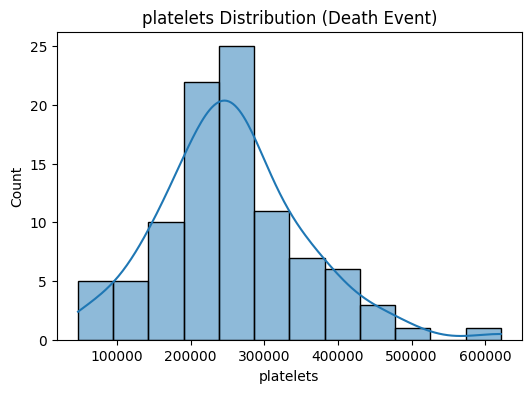

In [ ]:
death_patients = df[df['DEATH_EVENT'] == 1]  #died =  1,survived = 0

summary = death_patients.describe()

print(summary)

important_features = [
    'age',
    'ejection_fraction',
    'serum_creatinine',
    'serum_sodium',
    'platelets'
]

for col in important_features:
    plt.figure(figsize=(6,4))
    sns.histplot(
        death_patients[col],
        kde=True                #KDE(Kernel Density Estimation.)curve shows the overall distribution trend
    )
    plt.title(f"{col} Distribution (Death Event)")
    plt.show()

## 8.Are older patients more likely to have lower ejection fractions? Analyse the relationship between age and ejection fraction.

Correlation: 0.060098363232912864


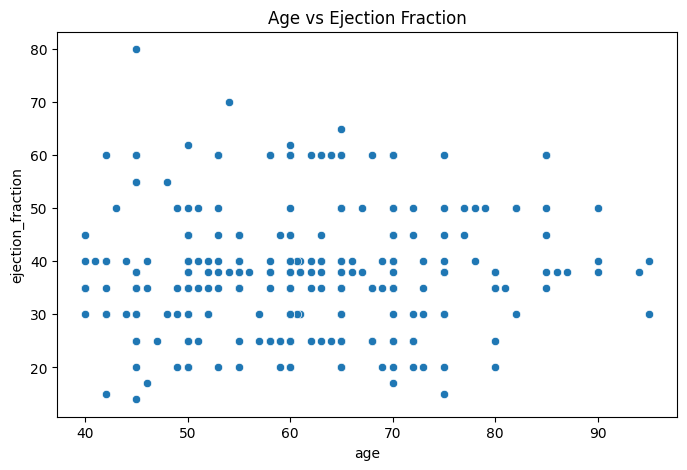

In [ ]:
corr = df['age'].corr(df['ejection_fraction'])

print("Correlation:", corr)

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='age',
    y='ejection_fraction',
    data=df
)

plt.title("Age vs Ejection Fraction")
plt.show()

The scatterplot does not show a strong linear relationship between age and ejection fraction. Although some older patients exhibit lower ejection fractions, considerable variability exists across all age groups. The correlation coefficient indicates a weak negative association, suggesting that age alone is not a strong predictor of ejection fraction in this dataset.

## 9.Based on your analysis, what are the top three recommendations you would provide to healthcare professionals to reduce mortality risk among heart failure patients?

Possible recommendations after analysis:

Monitor patients with low ejection fraction closely.
Control serum creatinine and kidney-related complications.
Prioritize elderly patients for frequent follow-up and intervention.

In [ ]:
risk_factors = df.corr(numeric_only=True)['DEATH_EVENT'] \
                  .sort_values(ascending=False)

print(risk_factors)          #better than a heatmap for correlating target-features

DEATH_EVENT                 1.000000
serum_creatinine            0.294278
age                         0.253729
high_blood_pressure         0.079351
anaemia                     0.066270
creatinine_phosphokinase    0.062728
diabetes                   -0.001943
sex                        -0.004316
smoking                    -0.012623
platelets                  -0.049139
serum_sodium               -0.195204
ejection_fraction          -0.268603
time                       -0.526964
Name: DEATH_EVENT, dtype: float64


## 10.Build a model that predicts your target value ( you can use any best algorithm )
## 11.Model Evaluation(Accuracy Score,Precision
•
Recall
•
F1-Score
•
Confusion Matrix
•
Interpret the results.)
•


In [ ]:
df['DEATH_EVENT'].value_counts()

DEATH_EVENT
0    203
1     96
Name: count, dtype: int64

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = df.drop(['DEATH_EVENT','age_group'], axis=1)
y = df['DEATH_EVENT']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,             
    test_size=0.2,
    random_state=42,
    stratify=y     #stratify=y is mainly useful for classification problems, especially when the classes are imbalanced.
)

rf = RandomForestClassifier(    #Random Forest doesn't need scaling because of how it makes decisions.A Random Forest is made up of many Decision Trees.(yes/no)  
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

Accuracy : 0.8166666666666667
Precision: 0.7857142857142857
Recall   : 0.5789473684210527
F1 Score : 0.6666666666666666


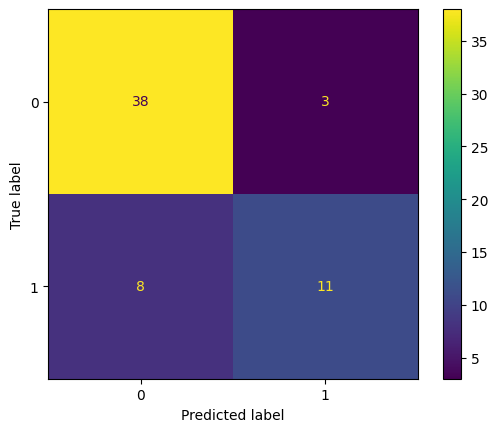

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()
plt.show()